In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL

In [3]:
df = pd.read_csv("Air Traffic Data Stationary.csv")
df.head(15)

,Date,domestic passengers_log_diff,international passengers_log_diff,domestic freight(in tonne)_log_diff,international freight(in tonne)_log_diff,GDP (in dollars)_log_diff,Population,Jet Fuel Price per Gallon_log_diff,Inflation Rate _log_diff,Unemployement Rate_log_diff,Rupees Exchange Rate_log_diff
0,2009-01-02,0.001585,-0.156494,-0.110912,0.066838,0.000000,1225524753,-0.146537,0.000000,0.000000,0.011230
1,2009-01-03,-0.053264,0.113350,0.211914,0.207414,0.000000,1225524753,0.047891,0.000000,0.000000,0.037462
2,2009-01-04,0.045174,0.015990,-0.063735,-0.056726,0.000000,1225524753,0.053022,0.000000,0.000000,-0.022949
3,2009-01-05,0.173060,0.041702,-0.101601,0.005086,0.000000,1225524753,0.052154,0.000000,0.000000,-0.029653
4,2009-01-06,-0.063824,0.005875,0.149680,0.003217,0.000000,1225524753,0.177301,0.000000,0.000000,-0.017468
5,2009-01-07,-0.027170,0.110634,0.087232,0.088559,0.000000,1225524753,-0.037575,0.000000,0.000000,0.014371
6,2009-01-08,0.016162,0.014692,0.142484,0.073768,0.000000,1225524753,0.092295,0.000000,0.000000,-0.002484
7,2009-01-09,-0.038350,-0.125087,-0.042653,-0.056222,0.000000,1225524753,-0.072387,0.000000,0.000000,0.001036
8,2009-01-10,0.124109,0.067928,0.094329,0.116915,0.000000,1225524753,0.068536,0.000000,0.000000,-0.034552
9,2009-01-11,-0.018282,0.004242,-0.034004,0.071981,0.000000,1225524753,0.019212,0.000000,0.000000,-0.002576


In [5]:
ts_data = df[['domestic passengers_log_diff']]

**Handling Missing values**

In [6]:
def seasonal_imputation(series,period=12):
    stl = STL(series.dropna(),period=period,robust=True)
    res = stl.fit()


    seasonal_component = res.seasonal
    deseasonalized = series - seasonal_component

    deseasonalized_imputed = deseasonalized.interpolate(method='linear')
    reconstructed = deseasonalized_imputed+seasonal_component
    return reconstructed 

In [8]:
ts_data['domestic passengers_log_diff'] = seasonal_imputation(ts_data['domestic passengers_log_diff'])

C:\Users\abhij\AppData\Local\Temp\ipykernel_21852\125149452.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_data['domestic passengers_log_diff'] = seasonal_imputation(ts_data['domestic passengers_log_diff'])


In [9]:
print("\nMissing values check after imputation:")
print(ts_data.isna().sum())


Missing values check after imputation:
domestic passengers_log_diff    0
dtype: int64


EDA

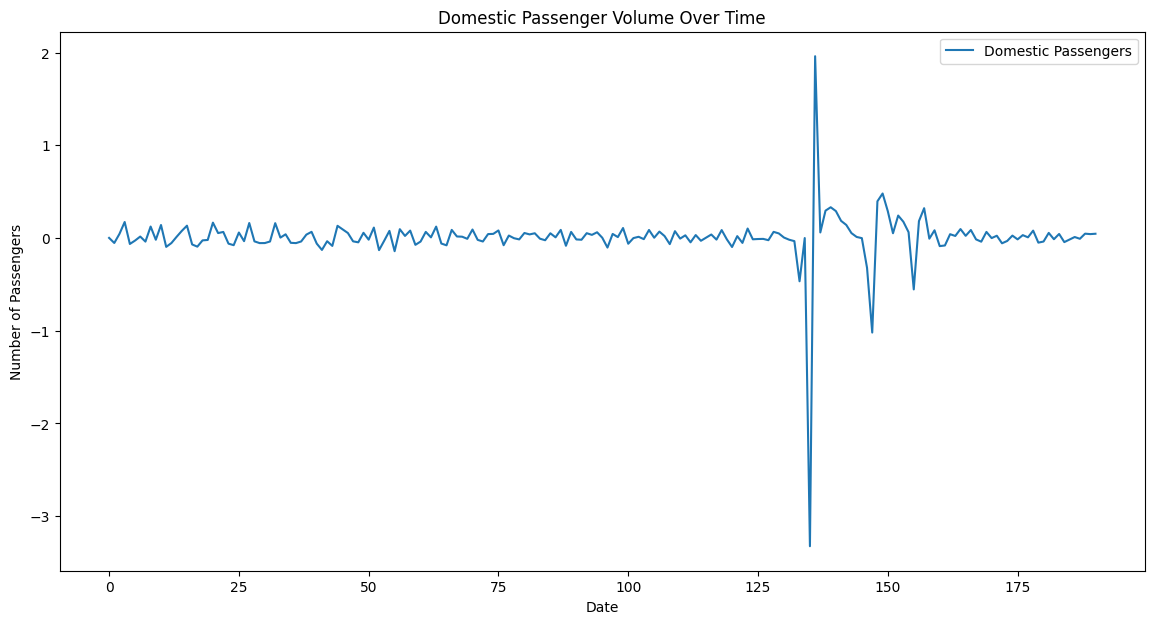

In [10]:
plt.figure(figsize=(14, 7))
plt.plot(ts_data.index, ts_data['domestic passengers_log_diff'], label='Domestic Passengers')
plt.title('Domestic Passenger Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
# Highlight the pandemic period for context
plt.legend()
plt.show()

STL Decomposition

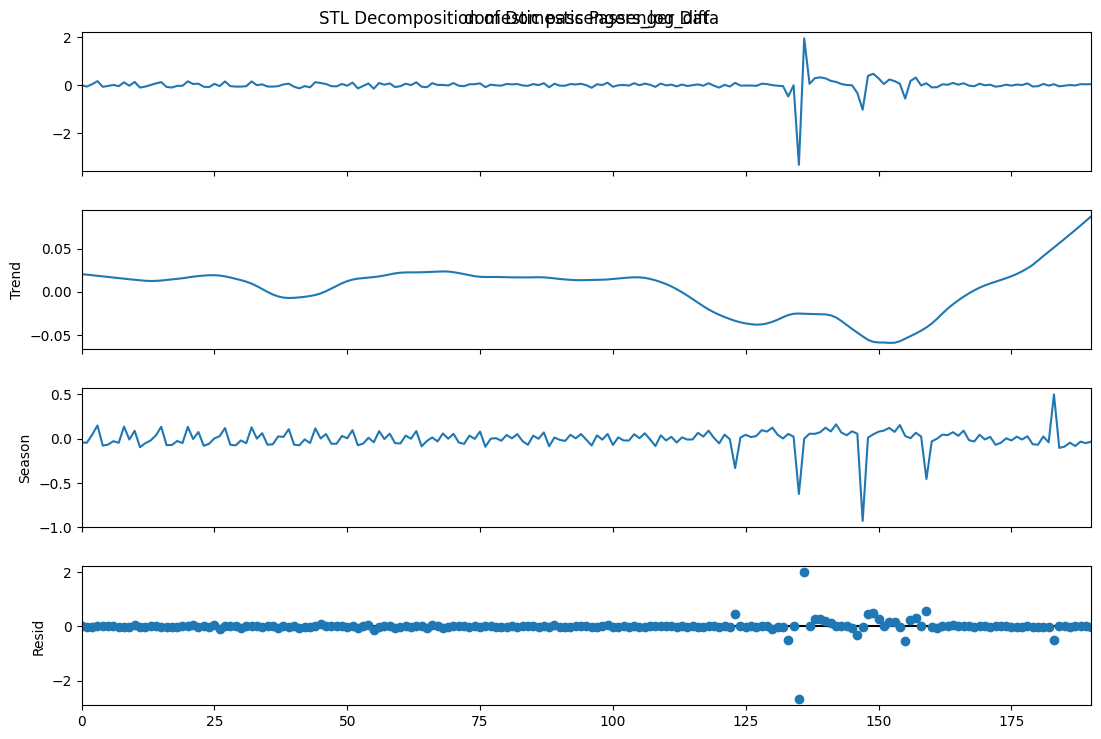

In [11]:
# Perform and plot the STL decomposition
stl = STL(ts_data['domestic passengers_log_diff'], period=12, robust=True)
res = stl.fit()
fig = res.plot()
fig.set_size_inches(12, 8)
plt.suptitle('STL Decomposition of Domestic Passenger Data', y=0.95)
plt.show()